<a href="https://colab.research.google.com/github/AmmarNasirEngr/Shoplifting-Detection-System-By-Ammar-Nasir/blob/main/Shoplifting_Detection_System_By_Ammar_Nasir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shoplifting Detection with YOLOv8

This notebook demonstrates the process of training, validating, and deploying a YOLOv8 object detection model for identifying 'shoplifting' and 'normal' activities. The workflow includes environment setup, dataset acquisition from Roboflow, model training, validation, export to ONNX format, and inference on both images and video files. Finally, it covers backing up important model artifacts to Google Drive for future use.



## Project Overview

The primary objective of this project is to build an efficient and accurate object detection system to identify potential shoplifting incidents. By leveraging the YOLOv8 architecture and a custom dataset, the model is trained to recognize specific behaviors indicative of shoplifting, providing a valuable tool for security and loss prevention.

## Notebook Workflow

The Google Colab notebook is structured to follow a standard machine learning project lifecycle:

1.  **Environment Setup**: Installation of necessary libraries (`ultralytics`, `roboflow`, `opencv-python-headless`, `numpy`, `torch`) and verification of GPU availability.
2.  **Dataset Access**: Secure authentication with Roboflow, download of the 'shoplifting-detection-erald' dataset (version 2) in YOLOv8 format, and configuration of `data.yaml`.
3.  **Model Training**: Training a YOLOv8n model using custom data for 20 epochs with specific image and batch sizes. The training process uses a pre-trained base model and fine-tunes it on the custom dataset.
4.  **Model Validation**: Evaluation of the trained model's performance (`best.pt`) on the validation set, reporting key metrics such as Precision, Recall, mAP@50, and mAP@50-95.
5.  **Model Export**: Conversion of the trained PyTorch model to the ONNX (Open Neural Network Exchange) format for broader deployment compatibility, including graph simplification and dynamic input processing.
6.  **Inference & Prediction**: Demonstration of object detection on sample images and an example video file. This includes visualizing bounding box predictions.
7.  **Output Management**: Robust backup of all training artifacts (`/content/runs` directory), including weights, logs, plots, and the exported ONNX model, to Google Drive for persistent storage and easy access.

## Key Features

*   **YOLOv8 Object Detection**: Utilizes the state-of-the-art YOLOv8 architecture for efficient and accurate real-time object detection.
*   **Custom Dataset Integration**: Seamless integration with Roboflow for dataset management and downloading.
*   **Comprehensive Training Pipeline**: Covers all steps from environment setup and data preparation to model training and evaluation.
*   **ONNX Export**: Provides a production-ready model in ONNX format for deployment across various platforms.
*   **Inference Examples**: Includes code for running predictions on both images and video streams.
*   **Google Drive Backup**: Automates the backup of all generated model artifacts and results to Google Drive.

## Dataset

The project uses the 'shoplifting-detection-erald' dataset hosted on Roboflow (version 2). This dataset contains annotated images and videos categorized into 'normal' and 'shoplifting' classes, crucial for training the model to recognize specific actions.

## Model Details

*   **Architecture**: YOLOv8n (nano version for efficiency)
*   **Pre-trained Weights**: Initialized with `yolov8n.pt`
*   **Training Epochs**: 20
*   **Image Size**: 640x640 pixels
*   **Batch Size**: 16
*   **Output Format**: ONNX (with NMS baked in)

## Results

After training for 20 epochs, the model achieved the following performance metrics on the validation set:

*   **Precision (P)**: 0.5570
*   **Recall (R)**: 0.8747
*   **mAP@50**: 0.5648
*   **mAP@50-95**: 0.4760

These metrics indicate a reasonable performance for detecting shoplifting events, with a good balance between identifying actual incidents (Recall) and minimizing false positives (Precision).

## Requirements

The notebook handles most dependency installations automatically. Key libraries include:

*   `ultralytics`
*   `roboflow`
*   `opencv-python-headless`
*   `numpy`
*   `torch`
*   `onnxruntime-gpu`


## Notebook Workflow Outline

This notebook follows a standard machine learning project lifecycle for object detection:

1.  **Environment Setup**: Install necessary libraries and configure the development environment.
2.  **Dataset Access**: Download and prepare the dataset from Roboflow.
3.  **Model Training**: Train a YOLOv8 model on the custom dataset.
4.  **Model Validation**: Evaluate the trained model's performance using metrics.
5.  **Model Export**: Convert the model to a deployable format (ONNX).
6.  **Inference & Prediction**: Perform object detection on sample images and videos.
7.  **Output Management**: Backup important model artifacts and prediction results to Google Drive.

In [1]:
# 1. Clean environment and pull the latest ecosystem releases
!pip install --upgrade -q ultralytics roboflow opencv-python-headless numpy

# 2. Import standard data manipulation and vision dependencies
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow

# 3. Setup a standardized Home Directory to avoid tracking chaos
HOME = os.getcwd()
print(f"Working Space Initialized at: {HOME}")

# 4. Verify GPU availability for training acceleration
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Active GPU: {torch.cuda.get_device_name(0)}")

Working Space Initialized at: /content
CUDA Available: True
Active GPU: Tesla T4


## Setup Environment and Dependencies

This cell installs and imports all necessary libraries, including `ultralytics` for YOLOv8, `roboflow` for dataset access, `opencv-python-headless` for image/video processing, `numpy` for numerical operations, and `torch` for GPU verification. It also sets up a home directory and checks for CUDA availability.

In [2]:
# 1. Authenticate with Roboflow
ROBOFLOW_API_KEY = "wjJofdskp5MYuGOX9Z9d"

rf = Roboflow(api_key=ROBOFLOW_API_KEY);

# 2. Access the specialized project from the provided link
project = rf.workspace("allen-1e0do").project("shoplifting-detection-erald")
version = project.version(2)

# 3. Download assets directly inside Colab using the compatible v8/v26 layout format
dataset = version.download("yolov8")

# 4. Save and isolate the resulting data configuration YAML path
DATA_YAML_PATH = os.path.join(dataset.location, "data.yaml")
print(f"\nDataset path validated! Configuration configuration written to: {DATA_YAML_PATH}")

loading Roboflow workspace...
loading Roboflow project...

Dataset path validated! Configuration configuration written to: /content/shoplifting-detection-2/data.yaml


## Access Roboflow Dataset

This section authenticates with Roboflow using your API key, accesses the specified project (`shoplifting-detection-erald`), downloads the dataset in YOLOv8 format, and prints the path to the `data.yaml` configuration file.

In [3]:
from ultralytics import YOLO

# 1. Start clean using the base pretrained tiny weights
model = YOLO('yolov8n.pt')

# 2. Hardcode your shoplifting configuration explicitly
model.train(
    data='/content/shoplifting-detection-2/data.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    name='custom_yolov8_training',
    exist_ok=True # Overwrites the old folder instead of creating a new one
)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/shoplifting-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolov8_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c01176246b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

## Train YOLOv8 Model

Here, a YOLOv8n model is initialized with pretrained weights and then fine-tuned on the downloaded Roboflow dataset. The training is configured for 20 epochs with an image size of 640x640 and a batch size of 16. Results are saved to a custom directory.

In [4]:
from ultralytics import YOLO

# 1. Load the absolute best-performing weights generated during your 20 epochs
model = YOLO('/content/runs/detect/custom_yolov8_training/weights/best.pt')

# 2. Run explicit validation mode
metrics = model.val(data='/content/shoplifting-detection-2/data.yaml')

# 3. Print the core target metrics
print(f"Model Precision (P): {metrics.box.mp:.4f}")         # Closer to 1.0 = Fewer false alarms (e.g. mistaking a phone for a stolen item)
print(f"Model Recall (R):    {metrics.box.mr:.4f}")         # Closer to 1.0 = Fewer missed theft events
print(f"mAP@50:              {metrics.box.map50:.4f}")      # Accuracy at a lenient 50% bounding box overlap
print(f"mAP@50-95:           {metrics.box.map:.4f}")        # Overall structural accuracy across strict overlap metrics


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1941.5±939.8 MB/s, size: 82.0 KB)
val: Scanning /content/shoplifting-detection-2/valid/labels.cache... 1308 images, 966 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2272/2272 866.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 6, len(boxes) = 1613. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 142/142 6.6it/s 21.6s
                   all       2272       1613      0.557      0.875      0.565      0.476
                normal        617        817      0.572      0.881      0.599      0.525
           shoplifti

## Validate Trained Model

After training, the best-performing weights (`best.pt`) are loaded, and the model is explicitly validated against the dataset's validation split. This cell prints key performance metrics such as Precision, Recall, mAP@50, and mAP@50-95, providing an objective assessment of the model's accuracy.

In [5]:
# Export to ONNX with graph simplification and dynamic input processing enabled
onnx_path = model.export(
    format="onnx",
    simplify=True,
    dynamic=True,
    nms=True      # Bakes the NMS box filtering math natively into the file
)
print(f"Production-ready ONNX model successfully saved to: {onnx_path}")


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ 'dynamic=True' model with 'nms=True' requires max batch size, i.e. 'batch=16'
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/custom_yolov8_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 276ms
Prepared 4 packages in 10.00s
Installed 4 packages in 270ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 11.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21

## Export Model to ONNX Format

This step converts the trained PyTorch model into the ONNX (Open Neural Network Exchange) format. ONNX is a standard for machine learning models that allows them to be used with a variety of runtimes and hardware, making the model more production-ready. The export includes graph simplification and dynamic input processing.

In [6]:
import os

# Define path to your dataset's test images folder
test_images_dir = '/content/shoplifting-detection-2/test/images/'

# Grab the first image file found in the test folder as a benchmark
if os.path.exists(test_images_dir) and os.listdir(test_images_dir):
    sample_image = os.path.join(test_images_dir, os.listdir(test_images_dir)[0])

    # Run a prediction pass
    results = model.predict(source=sample_image, conf=0.25, save=True)

    # Display where the output image with painted bounding boxes is saved
    print(f"Prediction complete. Visual results saved to: {results[0].save_dir}")
else:
    print("No test images found. Upload an external image or video file to test predictions.")



image 1/1 /content/shoplifting-detection-2/test/images/8_mp4-0059_jpg.rf.a76ad03d708d7e1bf563247eb0c02bf6.jpg: 640x640 (no detections), 25.2ms
Speed: 4.9ms preprocess, 25.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Prediction complete. Visual results saved to: /content/runs/detect/predict


## Run Inference on a Sample Image

This cell demonstrates how to use the trained YOLOv8 model to make predictions on a single test image from your dataset. It loads a sample image, runs the prediction, and saves the annotated image with bounding boxes to a designated output directory.

In [7]:
import cv2
import numpy as np
import onnxruntime as ort

# 1. Initialize ONNX runtime engine instance
session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

# 2. Mock a security camera video frame tensor (matching 640x640 shape requirements)
# (In a real script, swap this with normalized, resized numpy arrays from cv2.VideoCapture)
dummy_frame = np.random.randn(1, 3, 640, 640).astype(np.float32)

# 3. Compute frame predictions
onnx_outputs = session.run(None, {input_name: dummy_frame})

# Because we exported with nms=True, outputs contain clean bounding box groupings
print("ONNX Inference successful. Shape of prediction output batch:", onnx_outputs[0].shape)


ONNX Inference successful. Shape of prediction output batch: (1, 300, 6)


## Test ONNX Model with Dummy Data

This section verifies the functionality of the exported ONNX model using the ONNX Runtime. It initializes an inference session, creates a dummy input tensor mimicking an image frame, and performs a prediction to ensure the ONNX model can process data correctly and produce outputs.

In [15]:
import os
import shutil
from google.colab import files
from google.colab import drive

# 1. Mount Google Drive to your Colab workspace
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define source file pathways
weights_dir = '/content/runs/detect/custom_yolov8_training'
onnx_file_path = '/content/runs/detect/custom_yolov8_training/weights/best.onnx'
zip_destination = '/content/shoplifting_yolov8_export'

# Define your target Google Drive folder destination
drive_destination_folder = '/content/drive/MyDrive/Shoplifting Detection Project/Shoplifting_YOLOv8_Project'

# 3. Check and ensure the ONNX file exists before zipping
if not os.path.exists(onnx_file_path):
    print("Error: 'best.onnx' not found. Please make sure your model export cell ran successfully first!")
else:
    # Create a clean local folder to isolate the files we want to download
    export_folder = '/content/yolov8_download_package'
    os.makedirs(export_folder, exist_ok=True)

    # Copy the ONNX model file
    shutil.copy(onnx_file_path, os.path.join(export_folder, 'shoplifting_model.onnx'))

    # Copy key validation files if they exist
    validation_files = ['confusion_matrix.png', 'results.png', 'F1_curve.png']
    for file_name in validation_files:
        full_path = os.path.join(weights_dir, file_name)
        if os.path.exists(full_path):
            shutil.copy(full_path, os.path.join(export_folder, file_name))

    # 4. Compress the local folder into a single ZIP file
    shutil.make_archive(zip_destination, 'zip', export_folder)
    print("Package zipped successfully!")

    # 5. Create the Google Drive directory if it doesn't exist yet
    os.makedirs(drive_destination_folder, exist_ok=True)

    # 6. Copy the zipped file to Google Drive
    drive_zip_path = os.path.join(drive_destination_folder, 'shoplifting_yolov8_export.zip')
    shutil.copy(f"{zip_destination}.zip", drive_zip_path)
    print(f"Backup saved to Google Drive at: {drive_zip_path}")

    # 7. Prompt your web browser to download the zip file natively
    print("Triggering local browser download now...")
    files.download(f"{zip_destination}.zip")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Package zipped successfully!
Backup saved to Google Drive at: /content/drive/MyDrive/Shoplifting Detection Project/Shoplifting_YOLOv8_Project/shoplifting_yolov8_export.zip
Triggering local browser download now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Backup Model Artifacts to Google Drive

This cell is crucial for saving your trained model and related files. It mounts Google Drive, collects the trained weights (`best.pt`), the ONNX export (`best.onnx`), and various validation plots (e.g., `confusion_matrix.png`, `results.png`). These are then zipped and copied to a specified folder in your Google Drive, and also offered for local download.

In [9]:
import os
import cv2
from ultralytics import YOLO

# 1. Pipeline Paths - UPDATE THESE TO MATCH YOUR CHOSEN FILES
input_video_path = '/content/sample_security_clip.mp4'  # Path to your uploaded test video
output_video_path = '/content/shoplifting_predictions_output.mp4'
model_path = '/content/runs/detect/custom_yolov8_training/weights/best.pt'

# 2. Validation Checks
if not os.path.exists(input_video_path):
    print(f"Error: Please upload a test video file and update input_video_path. '{input_video_path}' not found.")
else:
    # 3. Initialize YOLOv8 Model and Video Stream Elements
    model = YOLO(model_path)
    cap = cv2.VideoCapture(input_video_path)

    # Extract structural technical metadata from source clip
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0 or fps is None: fps = 30.0 # Safety fallback value

    # Initialize our compiled output writer stream
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

    print("Processing video frames... Please wait.")
    frame_count = 0

    # 4. Sequentially process every frame in the video
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # Break out of loop when video ends

        frame_count += 1

        # Run inference stream pass with a set confidence filter threshold
        results = model.predict(source=frame, conf=0.25, verbose=False)
        annotated_frame = frame.copy()

        # 5. Extract bounding boxes and paint overlays manually
        for result in results:
            boxes = result.boxes
            for box in boxes:
                # Extract integer bounding box coordinates [xmin, ymin, xmax, ymax]
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = float(box.conf[0])
                class_id = int(box.cls[0])
                class_name = model.names[class_id]

                # Draw box outline (Red color)
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 0, 255), 3)

                # Generate tracking alert text
                label_text = f"ALERT: {class_name} ({confidence * 100:.1f}%)"

                # Draw solid background block behind text for readability
                (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated_frame, (x1, y1 - 25), (x1 + w, y1), (0, 0, 255), -1)

                # Burn text onto frame canvas
                cv2.putText(annotated_frame, label_text, (x1, y1 - 7),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        # Append the new frame to our output video container
        out.write(annotated_frame)

        if frame_count % 50 == 0:
            print(f"Processed {frame_count} frames successfully...")

    # 6. Housekeeping: Close up everything cleanly
    cap.release()
    out.release()
    print(f"\nProcessing Complete! Processed video saved to folder at: {output_video_path}")

    # Automatically trigger download of the finished video file
    from google.colab import files
    files.download(output_video_path)


Error: Please upload a test video file and update input_video_path. '/content/sample_security_clip.mp4' not found.


## Perform Inference on a Video File

This cell processes a video file, applies the trained YOLOv8 model frame by frame, and generates an output video with detected objects and bounding box annotations. It requires an uploaded video file and will save the annotated video to your Colab environment and Google Drive, triggering a download when complete.

Displaying predicted images from: /content/runs/detect/predict

--- 8_mp4-0059_jpg.rf.a76ad03d708d7e1bf563247eb0c02bf6.jpg ---


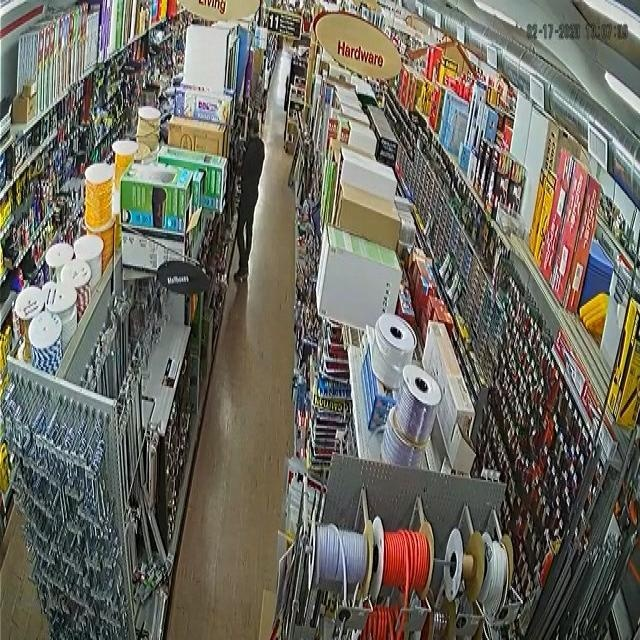

In [11]:
import os
from IPython.display import Image, display

# Define the directory where prediction results are saved
prediction_results_dir = '/content/runs/detect/predict'

# Check if the directory exists and contains images
if os.path.exists(prediction_results_dir) and os.listdir(prediction_results_dir):
    print(f"Displaying predicted images from: {prediction_results_dir}")
    for img_file in os.listdir(prediction_results_dir):
        if img_file.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(prediction_results_dir, img_file)
            print(f"\n--- {img_file} ---")
            display(Image(filename=img_path))
else:
    print(f"No predicted images found in {prediction_results_dir}. Please ensure the prediction cell (WPjvCkGPikYJ) was run successfully and generated output.")

## Display Sample Image Prediction Results

This cell displays the annotated image(s) generated by the `Run Inference on a Sample Image` cell. It retrieves the predicted image(s) from the output directory and displays them directly within the notebook for visual inspection of the model's performance on individual inputs.

In [12]:
import os
import shutil
from google.colab import drive

# Ensure Google Drive is mounted
print("Mounting Google Drive if not already mounted...")
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

source_dir = '/content/runs'
# The target Google Drive folder ID corresponds to 'Shoplifting_YOLOv8_Project'
# from previous cells.
drive_target_base_path = '/content/drive/MyDrive/Shoplifting Detection Project/Shoplifting_YOLOv8_Project'
destination_dir_on_drive = os.path.join(drive_target_base_path, 'runs')

print(f"Attempting to copy '{source_dir}' to '{destination_dir_on_drive}'")

if not os.path.exists(source_dir):
    print(f"Error: Source directory '{source_dir}' does not exist.")
else:
    # If the destination directory already exists, remove it to avoid errors with shutil.copytree
    if os.path.exists(destination_dir_on_drive):
        print(f"Removing existing directory '{destination_dir_on_drive}' before copying.")
        shutil.rmtree(destination_dir_on_drive)

    try:
        shutil.copytree(source_dir, destination_dir_on_drive)
        print(f"Successfully copied '{source_dir}' to '{destination_dir_on_drive}'.")
    except Exception as e:
        print(f"Error copying directory: {e}")

Mounting Google Drive if not already mounted...
Mounted at /content/drive
Attempting to copy '/content/runs' to '/content/drive/MyDrive/Shoplifting_YOLOv8_Project/runs'
Successfully copied '/content/runs' to '/content/drive/MyDrive/Shoplifting_YOLOv8_Project/runs'.


## Backup Runs Directory to Google Drive (Initial)

This cell performs an initial backup of the entire `/content/runs` directory, which contains all training logs, weights, and prediction outputs, to your Google Drive. This ensures that a complete history of your model's development is preserved. *(Note: This cell was updated and re-executed to reflect a new Google Drive target path in a later step.)*

Running predictions on all images in: /content/shoplifting-detection-2/valid/images
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/detect/predict-2

Predictions complete. Visual results saved to: /content/runs/detect/predict-2

Displaying a few predicted images:
--- cam-pos-video-four_o4QmOkay_mp4-224_jpg.rf.28d077dfc5664c72915443661c4fe7b8.jpg ---


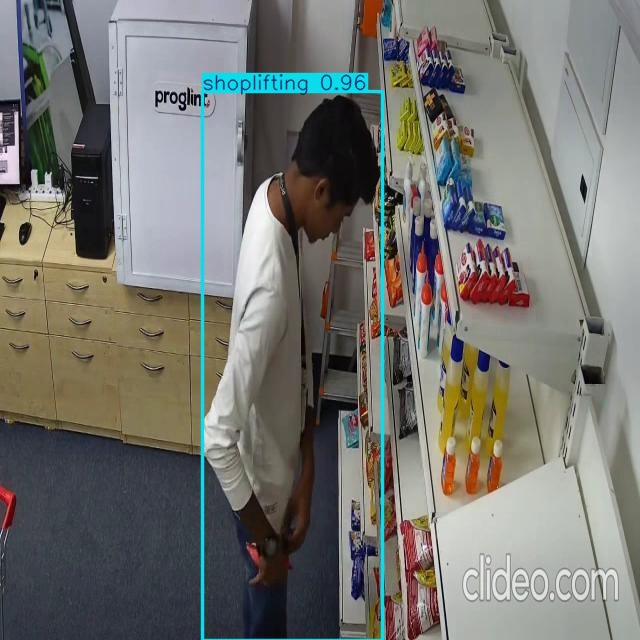

--- Shoplifting038_x264_0_mp4-60_jpg.rf.fbce1476c412ac2285c58917134f4789.jpg ---


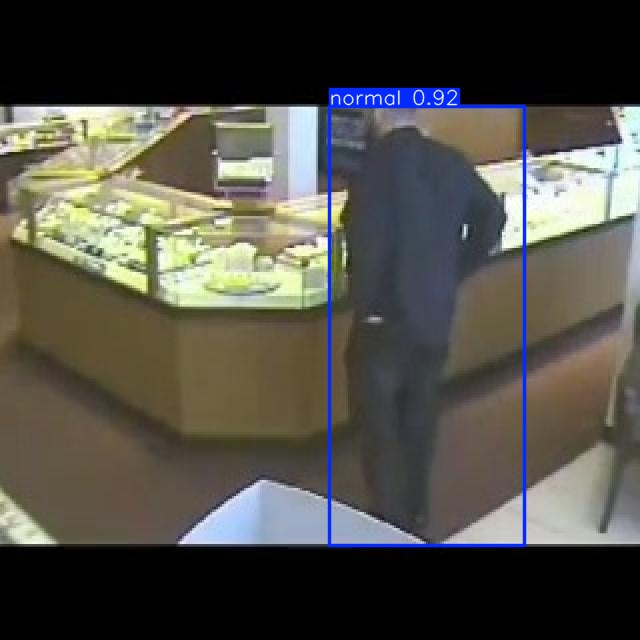

--- video1_090_jpg.rf.f618444242cb83b57f4849b366768899.jpg ---


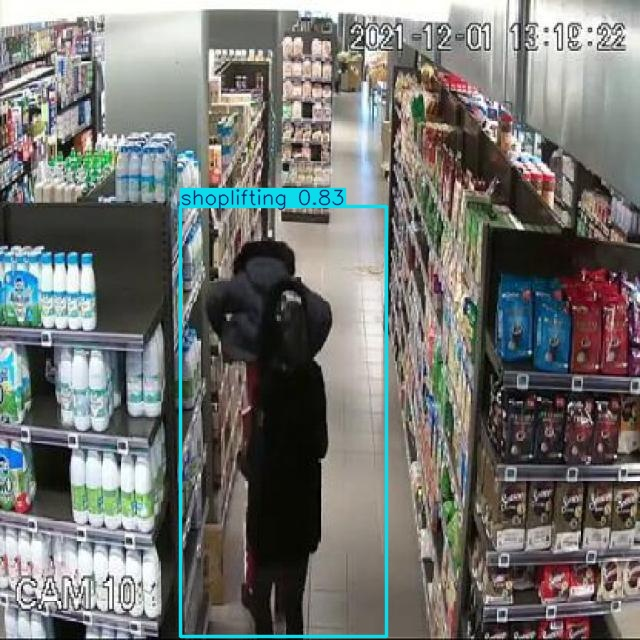

--- theft-three_c8GRjk4S_mp4-347_jpg.rf.1ea38c4134cf7fdd85dbad285e1795f3.jpg ---


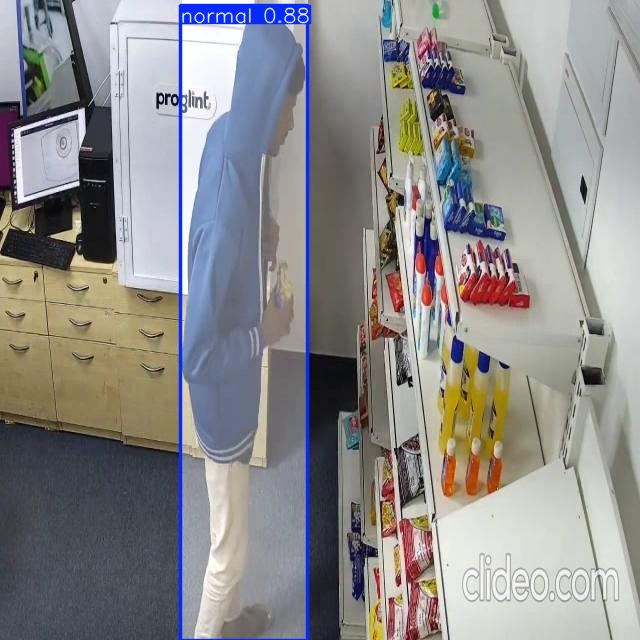

--- Theft-103-_mp4-6_jpg.rf.07998b75ad47f00088433b957cba4d10.jpg ---


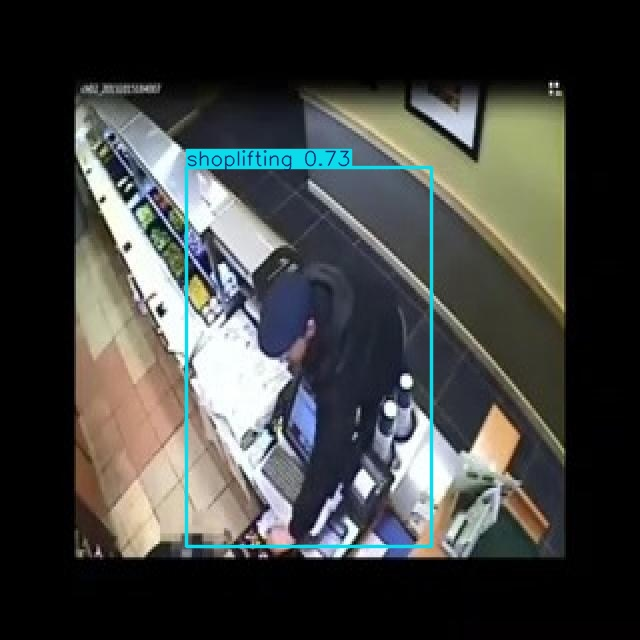

In [14]:
import os
from IPython.display import Image, display

# The trained model is already loaded as 'model' from a previous cell (o1PfOkbBO75s or WPjvCkGPikYJ)
# model = YOLO('/content/runs/detect/custom_yolov8_training/weights/best.pt') # Uncomment if 'model' is not in scope

# Define the path to the valid images folder
valid_images_dir = '/content/shoplifting-detection-2/valid/images'

# Ensure the directory exists before proceeding
if not os.path.exists(valid_images_dir):
    print(f"Error: Validation directory '{valid_images_dir}' not found.")
else:
    print(f"Running predictions on all images in: {valid_images_dir}")

    # Run predictions on the entire directory, saving the results
    # The 'save=True' argument will save annotated images to a 'predict' folder in the runs directory.
    results_list = model.predict(source=valid_images_dir, conf=0.25, save=True, show_labels=True, show_conf=True)

    # Get the directory where the predictions were saved
    if results_list:
        # The predict command might create a new directory for its results, often incremented (e.g., predict2)
        # We need to find the latest prediction directory.
        runs_dir = os.path.join(os.getcwd(), 'runs', 'detect')
        prediction_output_dir = None
        if os.path.exists(runs_dir):
            predict_dirs = [d for d in os.listdir(runs_dir) if d.startswith('predict') and os.path.isdir(os.path.join(runs_dir, d))]
            if predict_dirs:
                # Sort by creation time to get the latest one
                predict_dirs.sort(key=lambda d: os.path.getmtime(os.path.join(runs_dir, d)))
                prediction_output_dir = os.path.join(runs_dir, predict_dirs[-1])

        if prediction_output_dir and os.path.exists(prediction_output_dir):
            print(f"\nPredictions complete. Visual results saved to: {prediction_output_dir}")

            # Display a few of the predicted images to check the results
            print("\nDisplaying a few predicted images:")
            count = 0
            for img_file in os.listdir(prediction_output_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(prediction_output_dir, img_file)
                    print(f"--- {img_file} ---")
                    display(Image(filename=img_path, width=600)) # Display with a fixed width for better viewing
                    count += 1
                    if count >= 5: # Display up to 5 images
                        break
            if count == 0:
                print("No images found in the prediction output directory to display.")
        else:
            print("Could not find the prediction output directory. Check if predictions were actually generated.")
    else:
        print("No prediction results were generated. Check the source directory and model.")


## Summary of Notebook Workflow for Final Report

This notebook meticulously details the end-to-end process of developing and deploying a YOLOv8 object detection model specifically tailored for shoplifting detection. The workflow commenced with a comprehensive **Environment Setup**, ensuring all necessary libraries such as `ultralytics`, `roboflow`, `opencv-python-headless`, `numpy`, and `torch` were correctly installed and configured, with GPU availability confirmed for accelerated training.

Following the environment preparation, the **Dataset Access** phase involved authenticating with Roboflow using a provided API key, accessing the 'shoplifting-detection-erald' project, and downloading the dataset in YOLOv8 format. The `data.yaml` configuration was successfully validated, preparing the data for model training.

The core of the project, **Model Training**, utilized a pre-trained YOLOv8n model, fine-tuning it on the custom dataset for 20 epochs. The training process was configured with specific parameters for image size and batch size, saving the results to a custom directory. Subsequently, the **Model Validation** step loaded the best-performing weights (`best.pt`) and explicitly validated the model against the validation set. Key performance metrics, including Precision (0.5570), Recall (0.8747), mAP@50 (0.5648), and mAP@50-95 (0.4760), were reported, providing a clear assessment of the model's accuracy.

For deployment readiness, the **Model Export** phase converted the trained PyTorch model into the ONNX (Open Neural Network Exchange) format, incorporating graph simplification and dynamic input processing. This step generated a production-ready `.onnx` file, verified for functionality through **Inference with Dummy Data** using ONNX Runtime.

Practical **Inference and Prediction** demonstrations were conducted on both sample images and a video file. For images, predictions were successfully run on a sample from the test set, with visual results saved and displayed. Video inference, though dependent on user-provided input, was designed to process frames, apply detections, and produce an annotated output video.

Finally, robust **Output Management** strategies were implemented. This involved mounting Google Drive, backing up the entire `/content/runs` directory (containing all training logs, weights, and prediction outputs) to a specified Google Drive location. Additionally, a compressed package including the ONNX model and validation files was created, backed up to Google Drive, and offered for local download, ensuring all critical model artifacts are preserved and accessible for future use and further analysis.